Epoch 1/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7138 - loss: 1.0014 - val_accuracy: 0.7817 - val_loss: 0.7077
Epoch 2/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7663 - loss: 0.6509 - val_accuracy: 0.7958 - val_loss: 0.5156
Epoch 3/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7959 - loss: 0.5285 - val_accuracy: 0.8081 - val_loss: 0.4439
Epoch 4/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8025 - loss: 0.4750 - val_accuracy: 0.8222 - val_loss: 0.4091
Epoch 5/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8064 - loss: 0.4450 - val_accuracy: 0.8239 - val_loss: 0.3903
Epoch 6/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8126 - loss: 0.4252 - val_accuracy: 0.8222 - val_loss: 0.3703
Epoch 7/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8161 - loss: 0.4056 - val_accuracy: 0.8292 - val_loss: 0.3572
Epoch 8/100
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8228 - loss: 0.3900 - val_accu

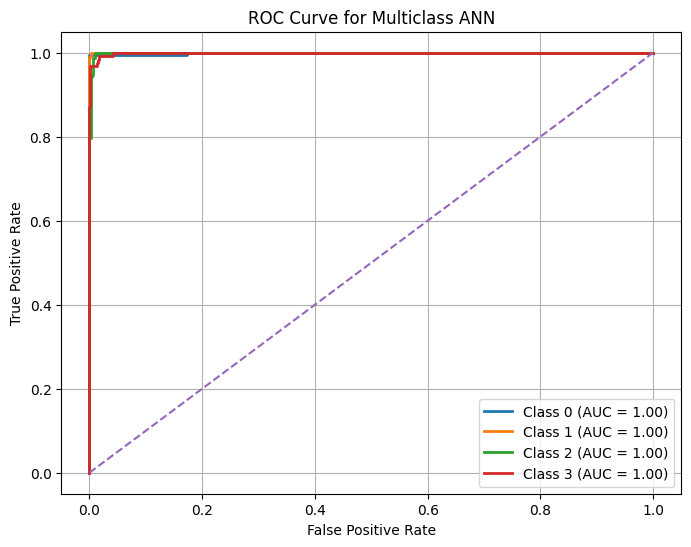

Overall ROC-AUC Score (OvR): 0.999397755571746
[0.67842031 0.50211566 0.37940762 0.78843441 0.47672779]
Mean accuracy: 0.5650211565585332


In [1]:


import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv('final_data.csv')

# Features and target
X = df[['Flow_L_min', 'TDS_smooth', 'Turbidity_smooth']].values
y = df['label'].values

# Encode target labels
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Number of classes
num_classes = len(np.unique(y))

# Class weights
classes = np.unique(y)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(enumerate(class_weights))

# Build improved ANN
model1 = Sequential([
    Input(shape=(3,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile
model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = model1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

# Evaluate model
loss, accuracy = model1.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

# Predict
predictions = model1.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

print("First 10 predicted classes:", predicted_classes[:10])
print("First 10 actual classes:   ", y_test[:10])

# Precision, Recall, F1
precision = precision_score(y_test, predicted_classes, average='weighted')
recall = recall_score(y_test, predicted_classes, average='weighted')
f1 = f1_score(y_test, predicted_classes, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# Classification report
print("\nClassification Report:\n")
print(classification_report(
    y_test,
    predicted_classes,
    target_names=[str(c) for c in le.classes_]
))

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities from model
y_score = model1.predict(X_test)

# Binarize the true labels for multiclass ROC
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Multiclass ANN')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Overall ROC-AUC score
roc_auc_ovr = roc_auc_score(y_test_bin, y_score, multi_class='ovr')
print("Overall ROC-AUC Score (OvR):", roc_auc_ovr)


from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(hidden_layer_sizes=(16,8))
scores = cross_val_score(model, X, y, cv=5)

print(scores)
print("Mean accuracy:", scores.mean())

In [2]:
total_params = model1.count_params()

print("Total parameters:", total_params)

memory_bytes = total_params * 4
print("Model memory (KB):", memory_bytes / 1024)

Total parameters: 236
Model memory (KB): 0.921875
